In [1]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd()
while _REPO_ROOT != _REPO_ROOT.parent and not (_REPO_ROOT / 'minervachem' / '__init__.py').exists():
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from minervachem.multi_search.optimization.utils import ParetoFront
from minervachem.multi_search.dataset.qm9_toy.compute_pareto import get_pareto
from minervachem.multi_search.plot_utils import (
    plot_pareto_fronts, c_metric, evaluate_pareto_quality,
)
# `plot_pareto_fronts_new` is optional in some library versions; fall back gracefully.
try:
    from minervachem.multi_search.plot_utils import plot_pareto_fronts_new
except ImportError:
    plot_pareto_fronts_new = plot_pareto_fronts

PAPERRUNS_QM9 = 'paperruns/qm9'
target_names = ['E_at', 'zvpe', 'e_gap', 'C_v']


In [2]:
meta_dfs = [
    pd.read_csv(f'{PAPERRUNS_QM9}/qm9_meta_{i}_E_at_zvpe_e_gap_C_v/pareto_fronts.csv')
    for i in range(5)
]
base_dfs = [
    pd.read_csv(f'{PAPERRUNS_QM9}/qm9_base_{i}_E_at_zvpe_e_gap_C_v/pareto_fronts.csv')
    for i in range(5)
]
random_dfs = [
    pd.read_csv(f'{PAPERRUNS_QM9}/qm9_random_{i}_E_at_zvpe_e_gap_C_v/pareto_fronts.csv')
    for i in range(5)
]


In [3]:
grouped_dfs = {
    'meta':   meta_dfs,
    'base':   base_dfs,
    'random': random_dfs,
}


In [4]:
GEN_TO_CHECK = 50

def pareto_size_stats(grouped_dfs, gen=GEN_TO_CHECK, build_pf=False):
    sizes, pf_groups = {}, ({} if build_pf else None)
    for alg, dfs in grouped_dfs.items():
        sizes_list, pf_list = [], []
        for df in dfs:
            sub = df[df['generation'] == gen]
            n = len(sub)
            sizes_list.append(n)
            if build_pf:
                Y = sub[target_names].to_numpy() if n > 0 else np.empty((0, len(target_names)))
                smiles = sub['SMILES'].tolist() if n > 0 else []
                pf = ParetoFront()
                pf.initialize_pareto(
                    X_list=[0.0]*len(Y) if len(Y) else [],
                    Y_list=Y if len(Y) else np.empty((0, len(target_names))),
                    smiles_list=smiles,
                )
                pf_list.append(pf)
        sizes[alg] = np.array(sizes_list, dtype=float)
        if build_pf:
            pf_groups[alg] = pf_list
        if sizes_list:
            print(f'{alg}: n_runs={len(sizes_list)} | Pareto size at gen={gen}: mean={np.mean(sizes_list):.2f}, std={np.std(sizes_list):.2f}')
    return (sizes, pf_groups) if build_pf else sizes

sizes_dict, pf_groups = pareto_size_stats(grouped_dfs, GEN_TO_CHECK, build_pf=True)
print('Sizes per algorithm at generation', GEN_TO_CHECK)
print(sizes_dict)


meta: n_runs=5 | Pareto size at gen=50: mean=19.20, std=1.17
base: n_runs=5 | Pareto size at gen=50: mean=19.60, std=1.62
random: n_runs=5 | Pareto size at gen=50: mean=21.20, std=4.49
Sizes per algorithm at generation 50
{'meta': array([21., 19., 20., 18., 18.]), 'base': array([20., 19., 20., 17., 22.]), 'random': array([20., 26., 14., 26., 20.])}


## Note

The original cell here called `plot_pareto_vs_spin_from_experiment` with SCO target indices `[0, 7, 8, 9]` — that helper expects an SCO experiment folder with `query_runs.csv`. QM9 paperruns don't include `query_runs.csv` and the indices don't match the four QM9 targets. See `post_process_sco_multiple.ipynb` for an equivalent SCO analysis.


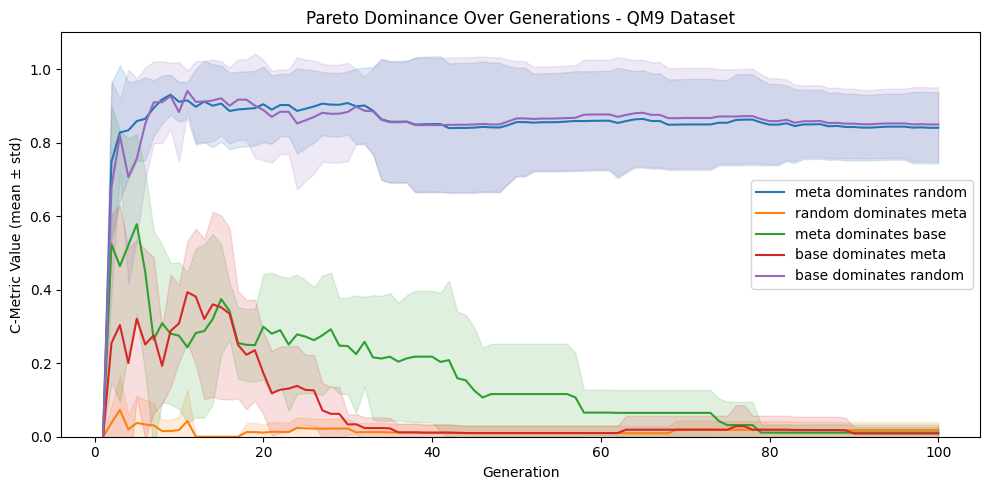

In [5]:
metrics = {
    'meta_dominates_random': [], 'random_dominates_meta': [],
    'meta_dominates_base':   [], 'base_dominates_meta':   [],
    'base_dominates_random': [],
}
errors = {k: [] for k in metrics}
generations = []
MAX_GEN = 100

for gen in range(1, MAX_GEN + 1):
    run_vals = {k: [] for k in metrics}
    for meta_df, base_df, rand_df in zip(meta_dfs, base_dfs, random_dfs):
        Y_meta = meta_df[meta_df['generation'] == gen][target_names].to_numpy()
        Y_base = base_df[base_df['generation'] == gen][target_names].to_numpy()
        Y_rand = rand_df[rand_df['generation'] == gen][target_names].to_numpy()
        if Y_meta.size and Y_rand.size:
            run_vals['meta_dominates_random'].append(c_metric(Y_meta, Y_rand))
            run_vals['random_dominates_meta'].append(c_metric(Y_rand, Y_meta))
        if Y_meta.size and Y_base.size:
            run_vals['meta_dominates_base'].append(c_metric(Y_meta, Y_base))
            run_vals['base_dominates_meta'].append(c_metric(Y_base, Y_meta))
        if Y_base.size and Y_rand.size:
            run_vals['base_dominates_random'].append(c_metric(Y_base, Y_rand))
    for key in metrics:
        if run_vals[key]:
            metrics[key].append(np.mean(run_vals[key]))
            errors[key].append(np.std(run_vals[key]))
        else:
            metrics[key].append(0.0); errors[key].append(0.0)
    generations.append(gen)

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(10, 5))
for i, key in enumerate(metrics):
    m = np.array(metrics[key]); s = np.array(errors[key])
    ax.plot(generations, m, label=key.replace('_', ' '), color=colors[i % len(colors)])
    ax.fill_between(generations, m - s, m + s, color=colors[i % len(colors)], alpha=0.15)
ax.set_xlabel('Generation'); ax.set_ylabel('C-Metric Value (mean ± std)')
ax.set_title('Pareto Dominance Over Generations - QM9 Dataset')
ax.set_ylim(0.0, 1.1); ax.legend(); fig.tight_layout(); plt.show()


In [6]:
# Stack final-gen meta and random for a union ParetoFront.
Y_meta_final = meta_dfs[0][meta_dfs[0]['generation'] == meta_dfs[0]['generation'].max()][target_names].to_numpy()
Y_rand_final = random_dfs[0][random_dfs[0]['generation'] == random_dfs[0]['generation'].max()][target_names].to_numpy()
Y_union = np.vstack([Y_meta_final, Y_rand_final])
print('Union shape:', Y_union.shape)

ref_pf = ParetoFront()
ref_pf.initialize_pareto(X_list=[0.0]*len(Y_union), Y_list=Y_union, smiles_list=[''] * len(Y_union))

res_meta_vs_random = evaluate_pareto_quality(
    pf_actual=pf_groups['random'][0], pf_reference=pf_groups['meta'][0]
)
print(res_meta_vs_random)


Union shape: (41, 4)
(20, 4)
(21, 4)
{'hypervolume': 0.3593351080551587, 'generational_distance': np.float64(0.23128345940514866), 'inverted_generational_distance': np.float64(0.26939467574834436), 'c_actual_dominates_pred': 0.95}


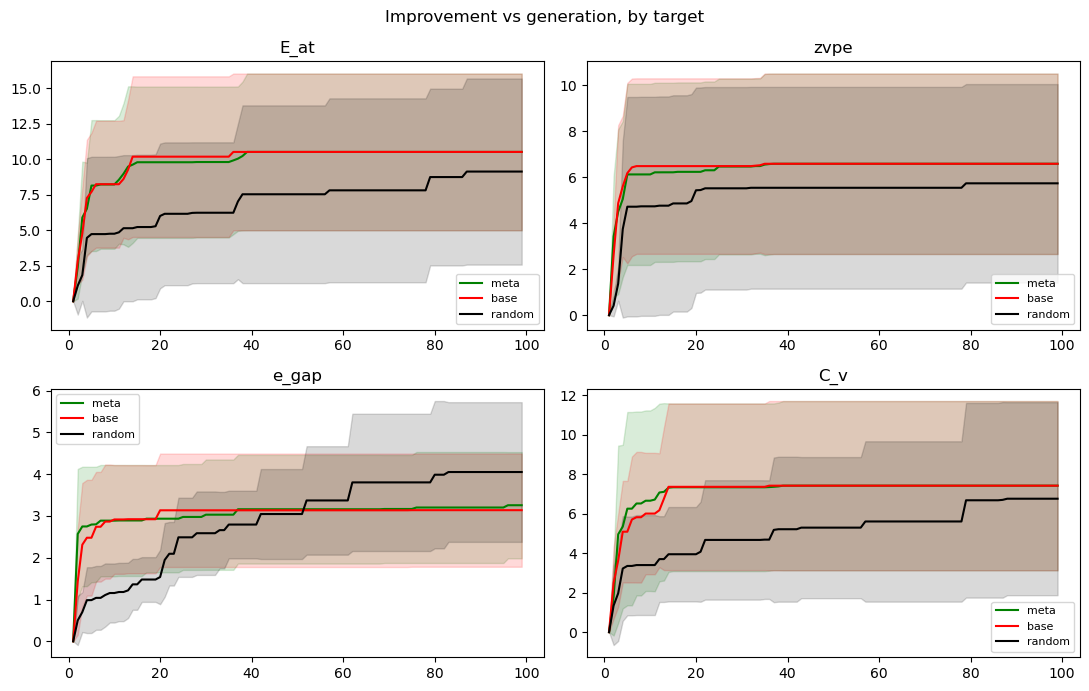

In [15]:
def ensemble_plot_all_algorithms_tiled(mean_improv, std_improv, targets, alg_color_map=None):
    if alg_color_map is None:
        alg_color_map = {'meta': 'green', 'base': 'red', 'random': 'black'}
    some = next(iter(mean_improv.keys()))
    n_gens = mean_improv[some].shape[1]
    gens = np.arange(1, n_gens + 1)
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    axes = axes.flatten()
    for i, t in enumerate(targets):
        ax = axes[i]
        for alg, M in mean_improv.items():
            color = alg_color_map.get(alg, 'gray')
            ax.plot(gens, M[i], label=alg, color=color)
            ax.fill_between(gens, M[i] - std_improv[alg][i], M[i] + std_improv[alg][i],
                            color=color, alpha=0.15)
        ax.set_title(t); ax.legend(fontsize=8)
    fig.suptitle('Improvement vs generation, by target', fontsize=12)
    fig.tight_layout(); plt.show()

ensemble_plot_all_algorithms_tiled(mean_improv, std_improv, target_names)
